In [1]:
import pandas as pd
from sqlalchemy import create_engine
from utils.database import get_engine
import seaborn as sns
import matplotlib.pyplot as plt

engine = get_engine()

In [2]:
df_supplier = pd.read_sql(
    "SELECT * FROM vw_supplier_performance",
    engine
)

df_supplier.head()

,supplier_name,avg_lead_time,avg_defect_rate,avg_manufacturing_cost
0,Supplier 3,20.13,2.47,43.63
1,Supplier 1,14.78,1.80,45.25
2,Supplier 5,18.06,2.67,44.77
3,Supplier 4,15.22,2.34,62.71
4,Supplier 2,18.55,2.36,41.62


In [3]:
df_supplier.columns


Index(['supplier_name', 'avg_lead_time', 'avg_defect_rate',
       'avg_manufacturing_cost'],
      dtype='object')

In [4]:
print(df_supplier.describe())

       avg_lead_time  avg_defect_rate  avg_manufacturing_cost
count       5.000000         5.000000                5.000000
mean       17.348000         2.328000               47.596000
std         2.281133         0.322909                8.563947
min        14.780000         1.800000               41.620000
25%        15.220000         2.340000               43.630000
50%        18.060000         2.360000               44.770000
75%        18.550000         2.470000               45.250000
max        20.130000         2.670000               62.710000


In [5]:
# Fast Supplier
df_supplier.sort_values(
    "avg_lead_time"
).head()

,supplier_name,avg_lead_time,avg_defect_rate,avg_manufacturing_cost
1,Supplier 1,14.78,1.80,45.25
3,Supplier 4,15.22,2.34,62.71
2,Supplier 5,18.06,2.67,44.77
4,Supplier 2,18.55,2.36,41.62
0,Supplier 3,20.13,2.47,43.63


In [6]:
#slow supplier
df_supplier.sort_values(
    "avg_lead_time",
    ascending=False
).head()

,supplier_name,avg_lead_time,avg_defect_rate,avg_manufacturing_cost
0,Supplier 3,20.13,2.47,43.63
4,Supplier 2,18.55,2.36,41.62
2,Supplier 5,18.06,2.67,44.77
3,Supplier 4,15.22,2.34,62.71
1,Supplier 1,14.78,1.80,45.25


## Lead Time Analysis

Lead time measures the time required for suppliers to deliver products.

### Key Findings
- Suppliers with lower lead times improve inventory responsiveness.
- Suppliers with higher lead times increase the risk of stock shortages and require higher safety stock levels.

In [7]:
#Best Quality Suppliers
df_supplier.sort_values(
    "avg_defect_rate"
).head()

,supplier_name,avg_lead_time,avg_defect_rate,avg_manufacturing_cost
1,Supplier 1,14.78,1.80,45.25
3,Supplier 4,15.22,2.34,62.71
4,Supplier 2,18.55,2.36,41.62
0,Supplier 3,20.13,2.47,43.63
2,Supplier 5,18.06,2.67,44.77


In [8]:
# Worst Quality Suppliers
df_supplier.sort_values(
    "avg_defect_rate",
    ascending=False
).head()


,supplier_name,avg_lead_time,avg_defect_rate,avg_manufacturing_cost
2,Supplier 5,18.06,2.67,44.77
0,Supplier 3,20.13,2.47,43.63
4,Supplier 2,18.55,2.36,41.62
3,Supplier 4,15.22,2.34,62.71
1,Supplier 1,14.78,1.80,45.25


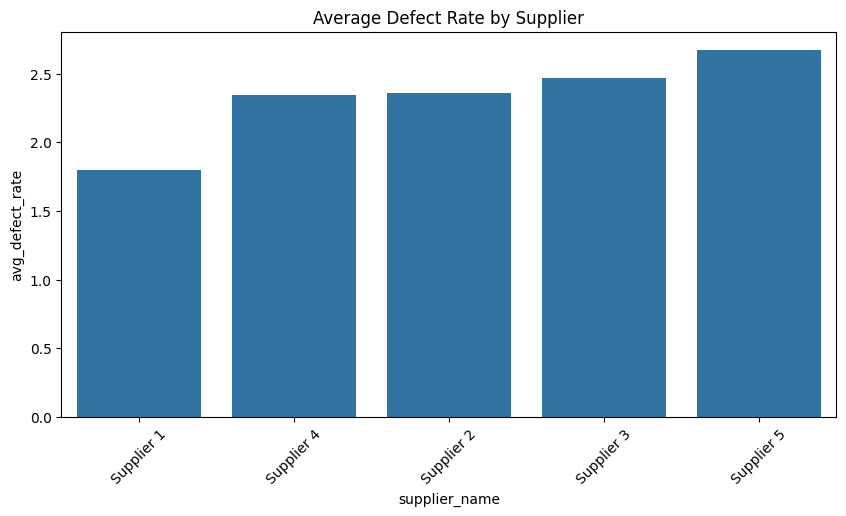

In [9]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_supplier.sort_values("avg_defect_rate"),
    x="supplier_name",
    y="avg_defect_rate"
)

plt.xticks(rotation=45)
plt.title("Average Defect Rate by Supplier")

plt.show()

In [10]:
# Cheapest Suppliers
df_supplier.sort_values(
    "avg_manufacturing_cost"
).head()

,supplier_name,avg_lead_time,avg_defect_rate,avg_manufacturing_cost
4,Supplier 2,18.55,2.36,41.62
0,Supplier 3,20.13,2.47,43.63
2,Supplier 5,18.06,2.67,44.77
1,Supplier 1,14.78,1.80,45.25
3,Supplier 4,15.22,2.34,62.71


In [11]:
# Most Expensive Suppliers
df_supplier.sort_values(
    "avg_manufacturing_cost",
    ascending=False
).head()

,supplier_name,avg_lead_time,avg_defect_rate,avg_manufacturing_cost
3,Supplier 4,15.22,2.34,62.71
1,Supplier 1,14.78,1.80,45.25
2,Supplier 5,18.06,2.67,44.77
0,Supplier 3,20.13,2.47,43.63
4,Supplier 2,18.55,2.36,41.62


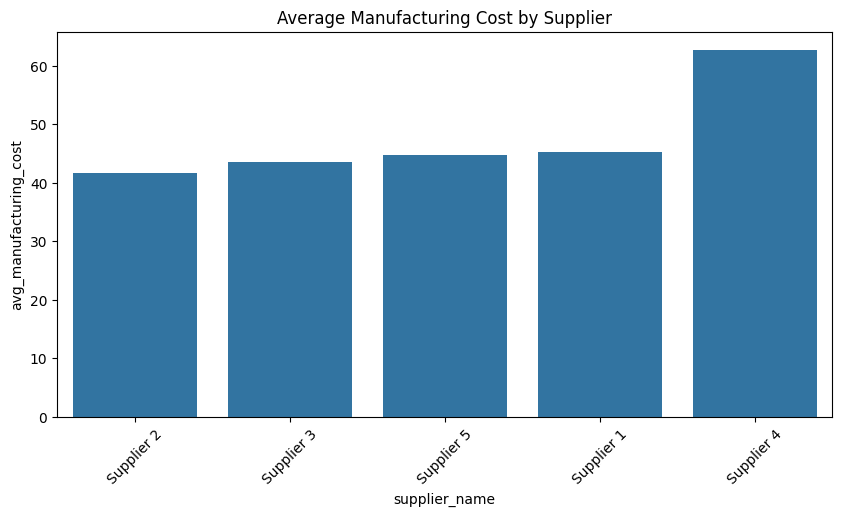

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_supplier.sort_values("avg_manufacturing_cost"),
    x="supplier_name",
    y="avg_manufacturing_cost"
)

plt.xticks(rotation=45)
plt.title("Average Manufacturing Cost by Supplier")

plt.show()

## Summary

Supplier analysis revealed significant differences in supplier performance across lead time, quality, and manufacturing cost metrics.

Key observations:

- Supplier 1 emerged as the strongest overall performer, combining the fastest lead time with the lowest defect rate.
- Supplier 2 offered the lowest manufacturing cost but demonstrated weaker operational performance compared to Supplier 1.
- Supplier 4 exhibited the highest manufacturing cost and may require cost optimization discussions.
- Supplier 5 showed the highest defect rate, indicating potential quality improvement opportunities.

These findings can support supplier evaluation, procurement decisions, and supply chain optimization initiatives.